MOHAMED ASLAM
24BAD073
EXPERIMENT 7

PART A: DATASET PREPARATION AND IMAGE PREPROCESSING

In [1]:
# MNIST GAN Experiment


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow Version:", tf.__version__)
print("MOHAMED ASLAM")

TensorFlow Version: 2.21.0
MOHAMED ASLAM


In [ ]:
# Load MNIST Handwritten Digits Dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [ ]:
# Check number of images and image dimensions

print("Number of training images:", len(x_train))
print("Image height:", x_train.shape[1])
print("Image width:", x_train.shape[2])
print("Image shape:", x_train[0].shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())

Number of training images: 60000
Image height: 28
Image width: 28
Image shape: (28, 28)
Pixel value range: 0 to 255


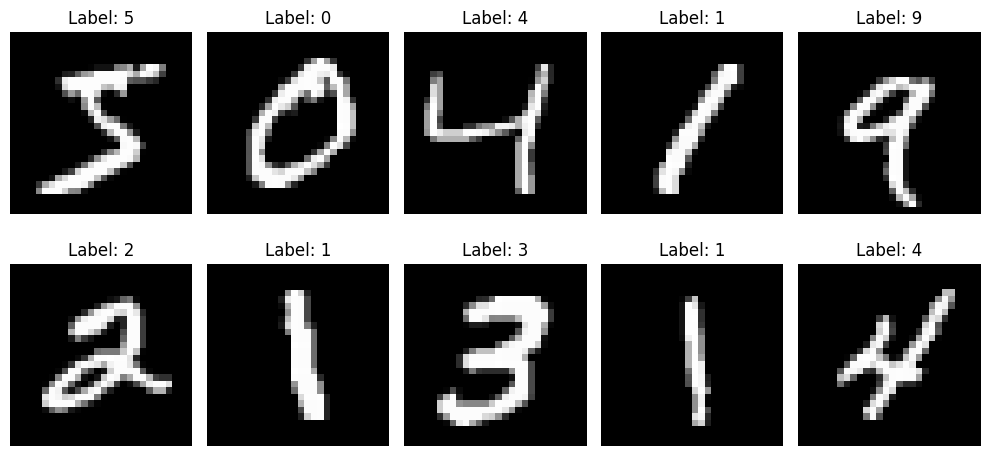

In [ ]:
# Display sample MNIST images

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Normalize pixel values from [0, 255] to [-1, 1]

x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

print("New pixel range:", x_train.min(), "to", x_train.max())

New pixel range: -1.0 to 1.0


In [ ]:
# Add channel dimension

x_train = np.expand_dims(x_train, axis=-1)

print("Reshaped training data:", x_train.shape)
print("Single image shape:", x_train[0].shape)

Reshaped training data: (60000, 28, 28, 1)
Single image shape: (28, 28, 1)


In [ ]:
# Batch-wise TensorFlow data pipeline

BATCH_SIZE = 128

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(60000)
    .batch(BATCH_SIZE)
)

print("Batch size:", BATCH_SIZE)
print("Data pipeline created successfully.")

Batch size: 128
Data pipeline created successfully.


## PART B — Implementing Generator

In [ ]:
# Generator Network

generator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(NOISE_DIM,)),
    tf.keras.layers.Dense(7 * 7 * 128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Reshape((7, 7, 128)),
    tf.keras.layers.Conv2DTranspose(
        64, kernel_size=4, strides=2, padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Conv2DTranspose(
        1, kernel_size=4, strides=2, padding="same",
        activation="tanh"
    )
])

print("Generator created successfully.")

Generator created successfully.


In [ ]:
# Display Generator architecture

generator.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 790,977 (3.02 MB)

 Trainable params: 778,305 (2.97 MB)

 Non-trainable params: 12,672 (49.50 KB)

In [ ]:
# Generate an image using random noise before training

random_noise = tf.random.normal([1, NOISE_DIM])

generated_image = generator(random_noise, training=False)

print("Generated image shape:", generated_image.shape)

Generated image shape: (1, 28, 28, 1)


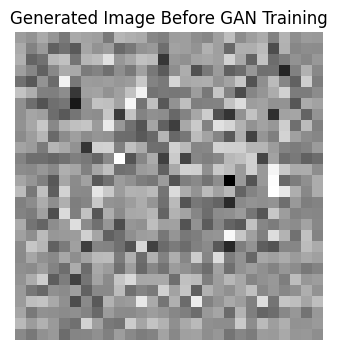

In [ ]:
# Display generated image before GAN training

plt.figure(figsize=(4, 4))
plt.imshow(
    generated_image[0, :, :, 0],
    cmap="gray"
)
plt.title("Generated Image Before GAN Training")
plt.axis("off")
plt.show()

## PART C — Discriminator and GAN

In [ ]:
# Discriminator Network

discriminator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(
        64, kernel_size=4, strides=2, padding="same"
    ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Conv2D(
        128, kernel_size=4, strides=2, padding="same"
    ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1)
])

print("Discriminator created successfully.")

Discriminator created successfully.


In [ ]:
# Display Discriminator architecture

discriminator.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,561 (541.25 KB)

 Trainable params: 138,561 (541.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Binary Cross Entropy Loss

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

# Optimizers
d_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

g_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

print("Loss function and optimizers created.")

Loss function and optimizers created.


In [ ]:
# Compile Discriminator

discriminator.compile(
    optimizer=d_optimizer,
    loss=cross_entropy,
    metrics=["accuracy"]
)

print("Discriminator compiled successfully.")

Discriminator compiled successfully.


In [ ]:
# Combine Generator and Discriminator

# Freeze discriminator only for the combined GAN
discriminator.trainable = False

gan_input = tf.keras.layers.Input(shape=(NOISE_DIM,))
generated_output = generator(gan_input)
gan_output = discriminator(generated_output)

gan = tf.keras.Model(
    gan_input,
    gan_output
)

print("Combined GAN created successfully.")

Combined GAN created successfully.


In [ ]:
# Compile the combined GAN

gan.compile(
    optimizer=g_optimizer,
    loss=cross_entropy
)

print("GAN Architecture:")
gan.summary()

GAN Architecture:


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28, 1)      │       790,977 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 1)              │       138,561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929,538 (3.55 MB)

 Trainable params: 778,305 (2.97 MB)

 Non-trainable params: 151,233 (590.75 KB)

## PART D — GAN Training and Synthetic Image Generation

In [ ]:
# GAN Training Configuration

EPOCHS = 20
NOISE_DIM = 100
NUM_EXAMPLES = 16

seed = tf.random.normal([NUM_EXAMPLES, NOISE_DIM])

generator_losses = []
discriminator_losses = []

os.makedirs("generated_images", exist_ok=True)

print("Epochs:", EPOCHS)
print("Noise dimension:", NOISE_DIM)
print("Training configuration ready.")

Epochs: 20
Noise dimension: 100
Training configuration ready.


In [ ]:
# Function to generate and save images during training

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    plt.figure(figsize=(8, 8))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(
            predictions[i, :, :, 0],
            cmap="gray"
        )
        plt.axis("off")

    plt.suptitle(f"Generated Images - Epoch {epoch}")
    plt.tight_layout()

    filename = f"generated_images/epoch_{epoch:03d}.png"
    plt.savefig(filename)
    plt.show()

    print("Saved:", filename)

Epoch 1/20 | D Loss: 1.2343 | G Loss: 0.7923
Epoch 2/20 | D Loss: 1.3301 | G Loss: 0.7825
Epoch 3/20 | D Loss: 1.2611 | G Loss: 0.8262
Epoch 4/20 | D Loss: 1.2415 | G Loss: 0.8519
Epoch 5/20 | D Loss: 1.2756 | G Loss: 0.8256


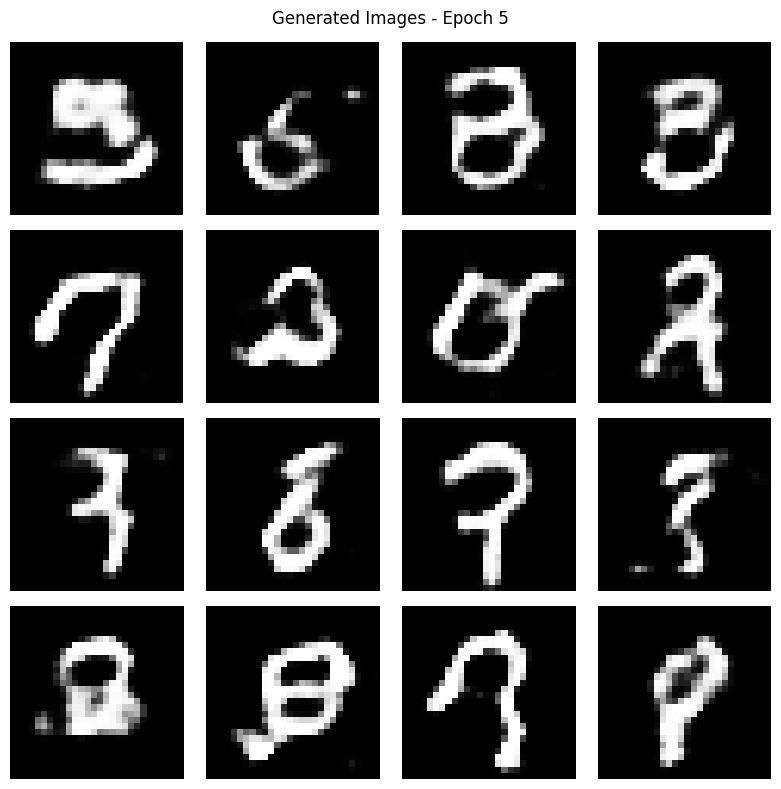

Saved: generated_images/epoch_005.png
Epoch 6/20 | D Loss: 1.2936 | G Loss: 0.8007
Epoch 7/20 | D Loss: 1.3064 | G Loss: 0.7916
Epoch 8/20 | D Loss: 1.3102 | G Loss: 0.7874
Epoch 9/20 | D Loss: 1.3132 | G Loss: 0.7780
Epoch 10/20 | D Loss: 1.3143 | G Loss: 0.7806


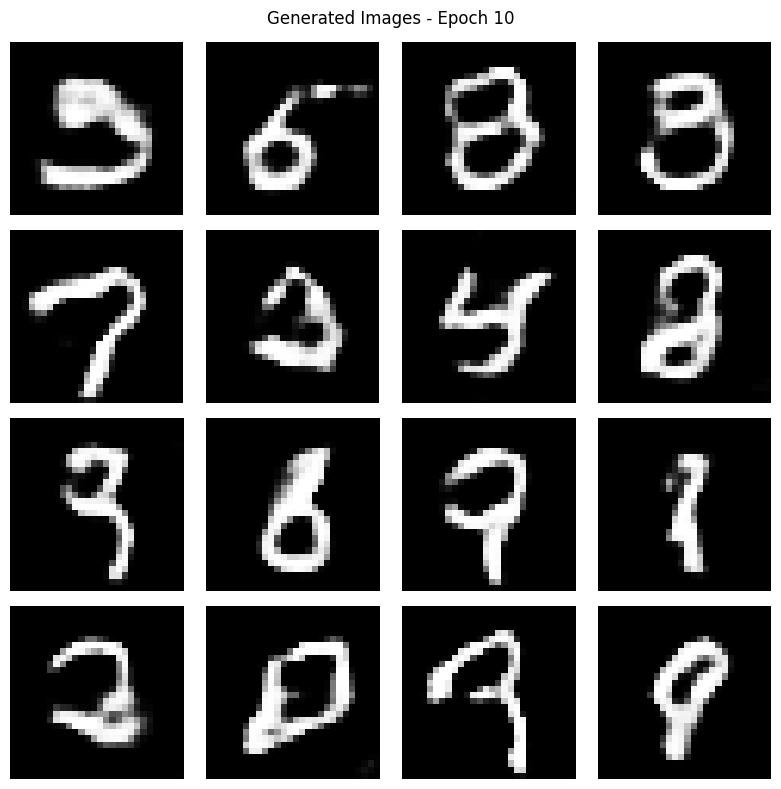

Saved: generated_images/epoch_010.png
Epoch 11/20 | D Loss: 1.3107 | G Loss: 0.7817
Epoch 12/20 | D Loss: 1.3048 | G Loss: 0.7894
Epoch 13/20 | D Loss: 1.3025 | G Loss: 0.7979
Epoch 14/20 | D Loss: 1.2961 | G Loss: 0.7906
Epoch 15/20 | D Loss: 1.2897 | G Loss: 0.7989


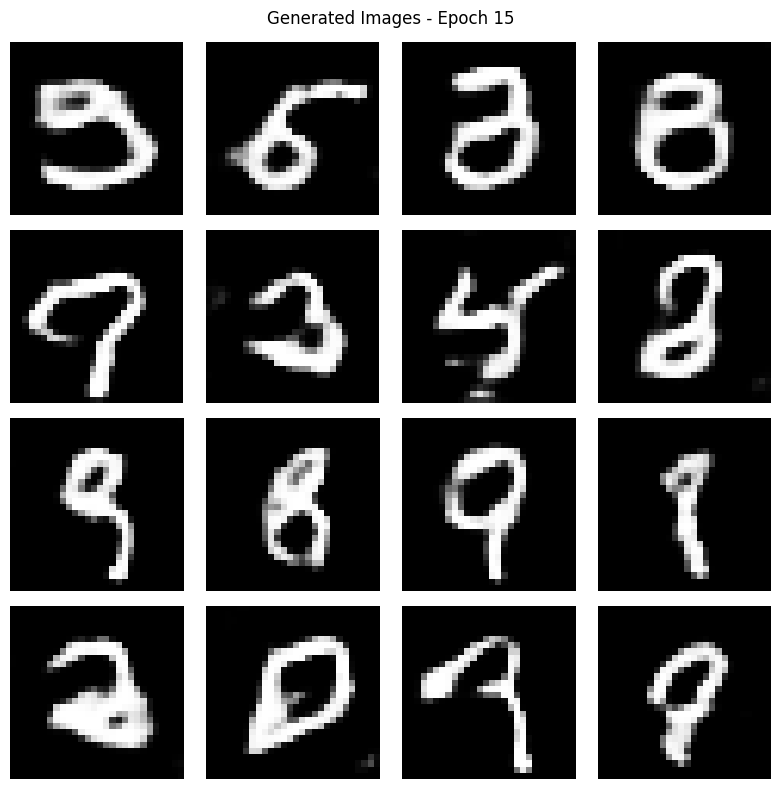

Saved: generated_images/epoch_015.png
Epoch 16/20 | D Loss: 1.2912 | G Loss: 0.8010
Epoch 17/20 | D Loss: 1.2888 | G Loss: 0.8004
Epoch 18/20 | D Loss: 1.2882 | G Loss: 0.8055
Epoch 19/20 | D Loss: 1.2848 | G Loss: 0.8051
Epoch 20/20 | D Loss: 1.2828 | G Loss: 0.8109


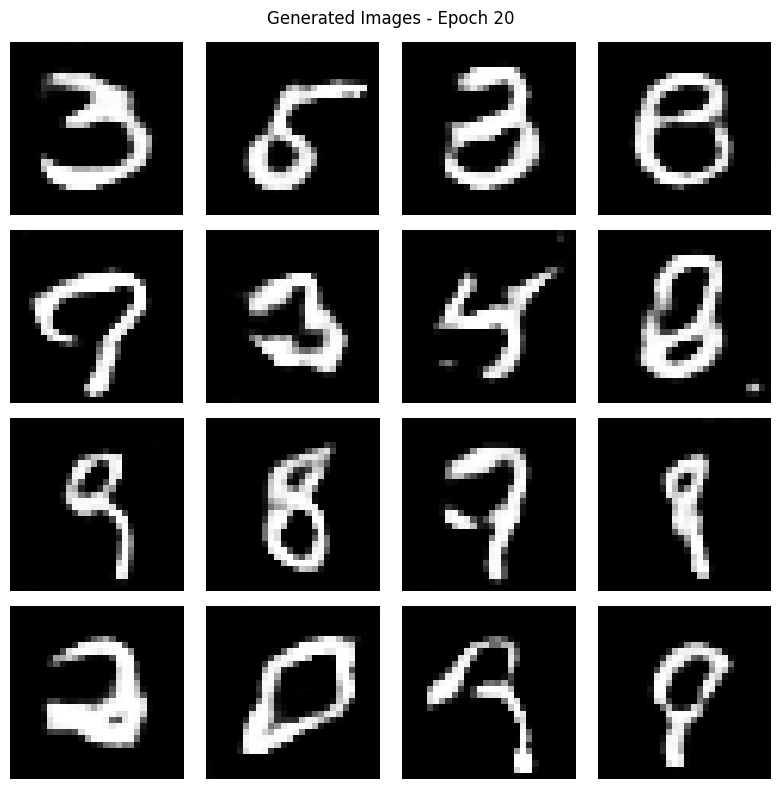

Saved: generated_images/epoch_020.png


In [ ]:
# GAN Training Loop

for epoch in range(1, EPOCHS + 1):

    d_loss_total = 0
    g_loss_total = 0
    batch_count = 0

    for real_images in train_dataset:

        batch_size = tf.shape(real_images)[0]

        # STEP 1: Train Discriminator
        noise = tf.random.normal([batch_size, NOISE_DIM])
        fake_images = generator(noise, training=True)

        discriminator.trainable = True

        with tf.GradientTape() as d_tape:
            real_output = discriminator(
                real_images,
                training=True
            )

            fake_output = discriminator(
                tf.stop_gradient(fake_images),
                training=True
            )

            real_loss = cross_entropy(
                tf.ones_like(real_output),
                real_output
            )

            fake_loss = cross_entropy(
                tf.zeros_like(fake_output),
                fake_output
            )

            d_loss = real_loss + fake_loss

        d_gradients = d_tape.gradient(
            d_loss,
            discriminator.trainable_variables
        )

        d_optimizer.apply_gradients(
            zip(
                d_gradients,
                discriminator.trainable_variables
            )
        )

        # STEP 2: Train Generator
        noise = tf.random.normal([batch_size, NOISE_DIM])

        with tf.GradientTape() as g_tape:
            generated_images = generator(
                noise,
                training=True
            )

            fake_output = discriminator(
                generated_images,
                training=False
            )

            g_loss = cross_entropy(
                tf.ones_like(fake_output),
                fake_output
            )

        g_gradients = g_tape.gradient(
            g_loss,
            generator.trainable_variables
        )

        g_optimizer.apply_gradients(
            zip(
                g_gradients,
                generator.trainable_variables
            )
        )

        d_loss_total += float(d_loss)
        g_loss_total += float(g_loss)
        batch_count += 1

    avg_d_loss = d_loss_total / batch_count
    avg_g_loss = g_loss_total / batch_count

    discriminator_losses.append(avg_d_loss)
    generator_losses.append(avg_g_loss)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"G Loss: {avg_g_loss:.4f}"
    )

    if epoch % 5 == 0:
        generate_and_save_images(
            generator,
            epoch,
            seed
        )

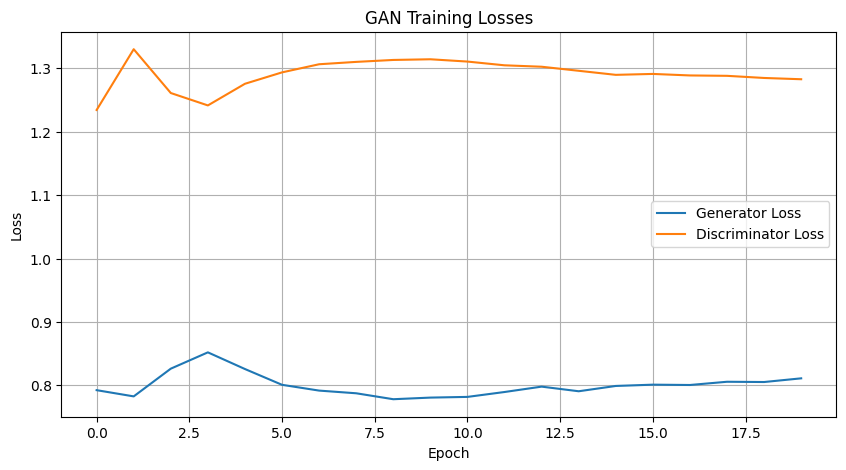

In [ ]:
# Plot GAN training losses

plt.figure(figsize=(10, 5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True)

plt.show()

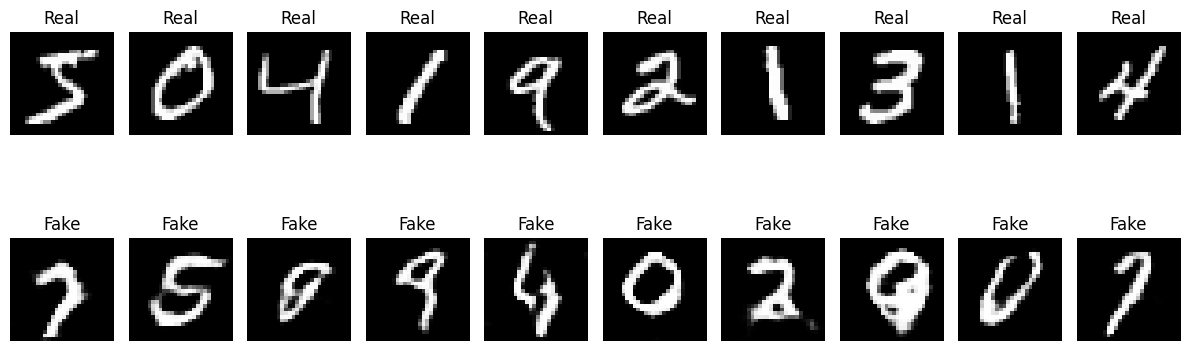

In [ ]:
# Generate synthetic images for comparison

noise = tf.random.normal([10, NOISE_DIM])

synthetic_images = generator(
    noise,
    training=False
)

plt.figure(figsize=(12, 5))

# Real images
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(
        x_train[i, :, :, 0],
        cmap="gray"
    )
    plt.title("Real")
    plt.axis("off")

# Synthetic images
for i in range(10):
    plt.subplot(2, 10, i + 11)
    plt.imshow(
        synthetic_images[i, :, :, 0],
        cmap="gray"
    )
    plt.title("Fake")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Generate and save 25 final synthetic images

os.makedirs("final_generated_images", exist_ok=True)

final_noise = tf.random.normal([25, NOISE_DIM])

final_images = generator(
    final_noise,
    training=False
)

for i in range(25):

    image = final_images[i, :, :, 0].numpy()

    # Convert from [-1, 1] to [0, 1]
    image = (image + 1) / 2

    plt.imsave(
        f"final_generated_images/generated_{i+1}.png",
        image,
        cmap="gray"
    )

print("25 final synthetic images saved successfully.")

25 final synthetic images saved successfully.


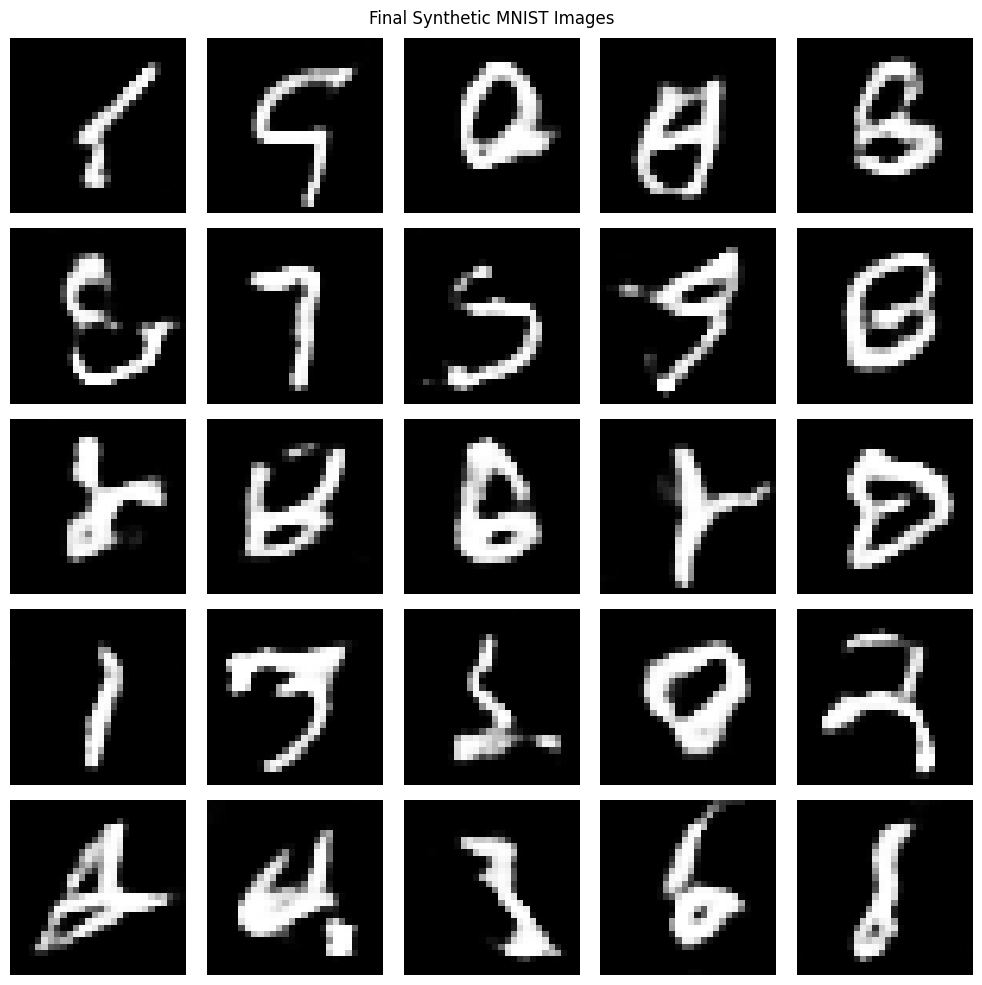

In [ ]:
# Display final generated images

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)

    image = final_images[i, :, :, 0]

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Final Synthetic MNIST Images")
plt.tight_layout()
plt.show()

In [ ]:
# Save trained Generator

generator.save(
    "mnist_gan_generator.keras"
)

print("Generator model saved successfully.")

Generator model saved successfully.


In [ ]:
# Check generated files

print("Generated image folders:")

print(
    "Training snapshots:",
    os.listdir("generated_images")
)

print(
    "Final images:",
    len(os.listdir("final_generated_images"))
)

print(
    "Generator model exists:",
    os.path.exists("mnist_gan_generator.keras")
)

Generated image folders:
Training snapshots: ['epoch_005.png', 'epoch_010.png', 'epoch_015.png', 'epoch_020.png']
Final images: 25
Generator model exists: True


In [ ]:
print("RESULT:")
print("The GAN was successfully trained on the MNIST handwritten digit dataset.")
print("The Generator learned to produce synthetic handwritten digit images.")
print("Generated images were saved successfully.")

RESULT:
The GAN was successfully trained on the MNIST handwritten digit dataset.
The Generator learned to produce synthetic handwritten digit images.
Generated images were saved successfully.
